/tmp/ipykernel_49364/3724759202.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap(cmap_name)


Loaded Midwest
Loaded Northeast
Loaded Northwest
Loaded Southeast
Loaded Southwest
Loaded Northern Great Plains
Loaded Southern Great Plains


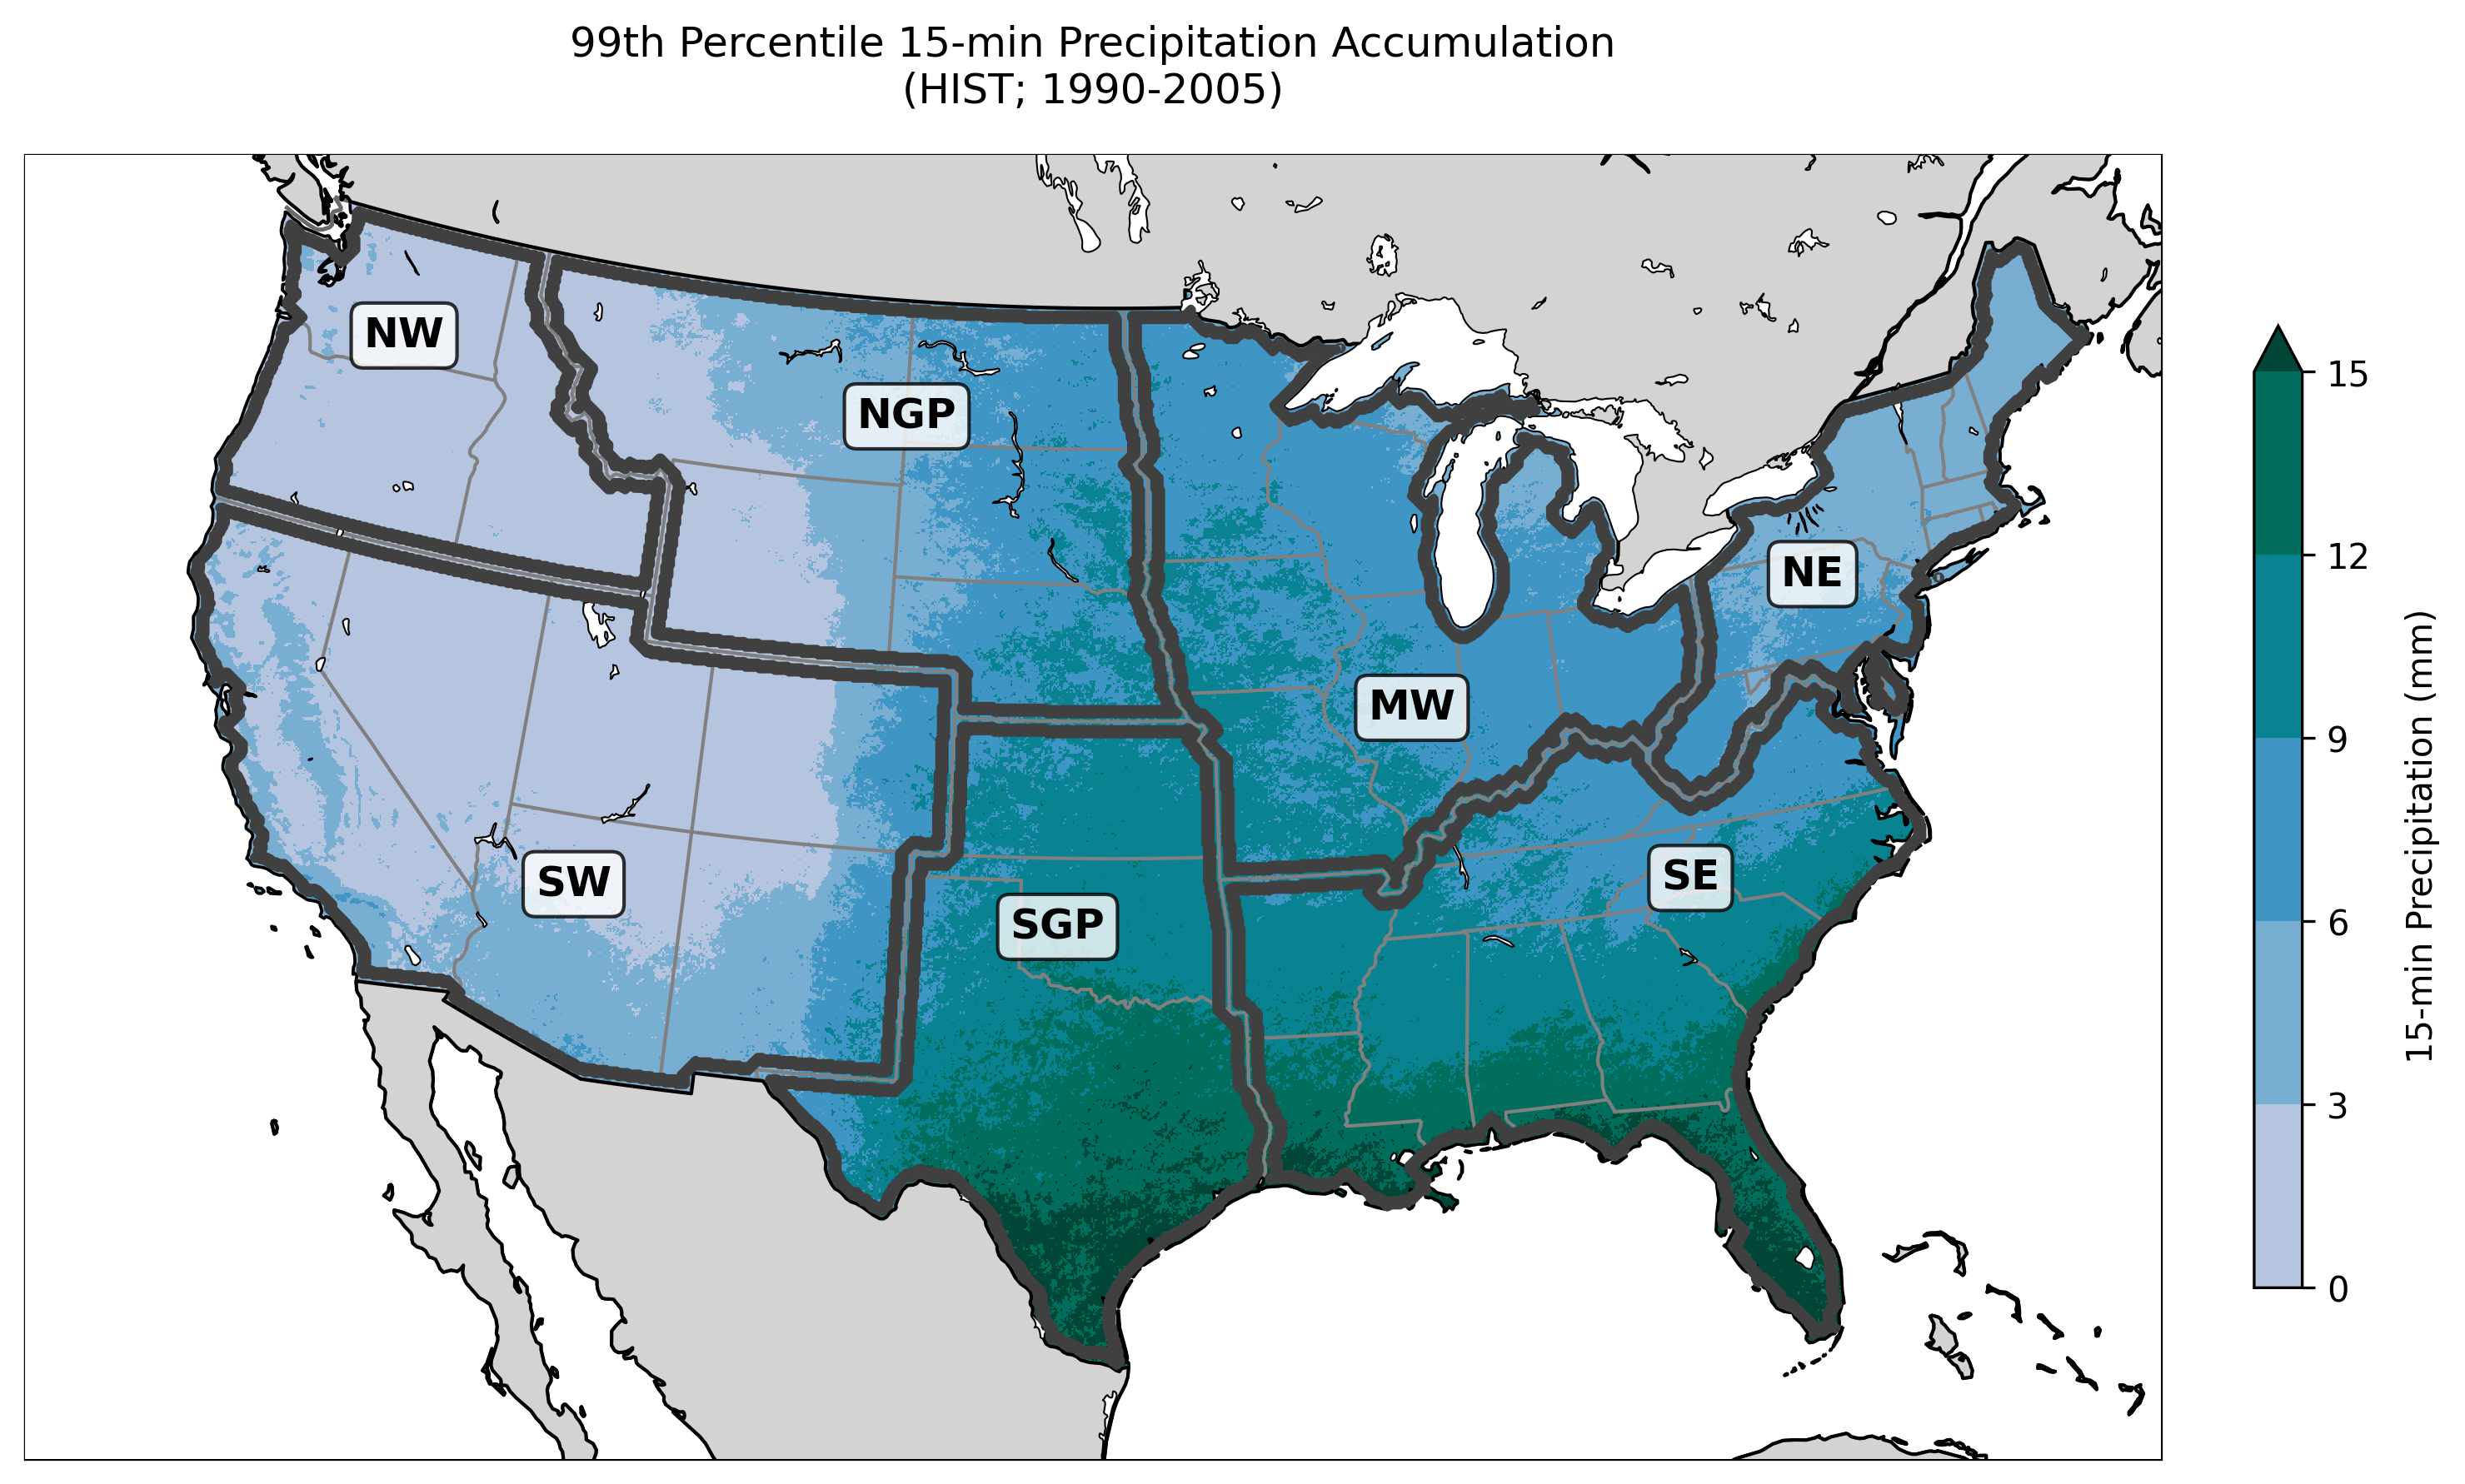

In [9]:
# ============================================================================
# Single Panel Figure Generation - Plotting Utility
# ============================================================================
# Creates map of precipitation fields
# Includes NCA region outlines and professional cartographic features
#
# ============================================================================
# PATH CONFIGURATION - EDIT THIS SECTION
# ============================================================================

# Set DATA_ROOT to the location where you extracted SDHI_Precip_supporting_data.tar.gz
DATA_ROOT = "/path/to/SDHI_Precip_supporting_data"  # <-- EDIT THIS LINE

# Derived paths (no editing needed below this line)
PATH_GRID = f"{DATA_ROOT}/geo_em.d01.nc"
PATH_PERCENTILES = f"{DATA_ROOT}/wet_period_percentiles_base0p254"
NCA_MASK_DIR = f"{DATA_ROOT}/masking"

# Output directory for figures (relative to notebook location)
OUTPUT_DIR = "./figures_single_panel"

# ============================================================================
# END CONFIGURATION
# ============================================================================

# %%
# Imports
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
from matplotlib.colors import ListedColormap
from matplotlib import colors, colormaps, ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cartopy.io.shapereader as shpreader
from scipy import ndimage

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# %%
# Utility functions
def downsample_ds(ds, aggregation_factor=(21,21), reducer='mean'):
    """Quick downsample for smoother plotting"""
    boundary = "trim"
    if reducer == "mean":
        return ds.coarsen(west_east=aggregation_factor[0], boundary=boundary).mean(skipna=True)\
                .coarsen(south_north=aggregation_factor[1], boundary=boundary).mean(skipna=True)
    elif reducer == "max":
        return ds.coarsen(west_east=aggregation_factor[0], boundary=boundary).max(skipna=True)\
                .coarsen(south_north=aggregation_factor[1], boundary=boundary).max(skipna=True)

def setup_colormap(cmap_name='PuBuGn', bins=11, vmin=0, vmax=270, trunc_min=0.2, trunc_max=1.0):
    """Create discrete colormap with arrows"""
    # Truncate and discretize
    base = plt.cm.get_cmap(cmap_name)
    trunc_cmap = colors.LinearSegmentedColormap.from_list(
        f'trunc_{cmap_name}', base(np.linspace(trunc_min, trunc_max, 100)))
    
    color_list = trunc_cmap(np.linspace(0, 1, bins))
    discrete_cmap = colors.ListedColormap(color_list[1:-1])
    discrete_cmap.set_over(color_list[-1])
    discrete_cmap.set_under(color_list[0])
    
    # Tick positions
    ticks = np.linspace(vmin, vmax, bins - 1)
    
    return discrete_cmap, ticks

def load_nca_regions(mask_dir):
    """Load NCA region masks and create outlines
    
    Parameters:
    -----------
    mask_dir : str
        Path to directory containing Masked_NCA_*.nc files
    """
    region_files = {
        'Midwest': 'Masked_NCA_Midwest.nc',
        'Northeast': 'Masked_NCA_Northeast.nc', 
        'Northwest': 'Masked_NCA_Northwest.nc',
        'Southeast': 'Masked_NCA_Southeast.nc',
        'Southwest': 'Masked_NCA_Southwest.nc',
        'Northern Great Plains': 'Masked_NCA_NorthernGreatPlains.nc',
        'Southern Great Plains': 'Masked_NCA_SouthernGreatPlains.nc'
    }
    
    # Colors for each region - all dark gray
    region_names = ['Midwest', 'Northeast', 'Northwest', 'Southeast', 'Southwest', 
                   'Northern Great Plains', 'Southern Great Plains']
    region_colors = {name: '#404040' for name in region_names}  # Dark gray for all regions
    
    regions = {}
    
    for region_name, filename in region_files.items():
        filepath = os.path.join(mask_dir, filename)
        if os.path.exists(filepath):
            try:
                # Load the mask file
                ds = xr.open_dataset(filepath)
                
                # Get the mask variable (might have different names)
                var_names = list(ds.data_vars.keys())
                if var_names:
                    mask_var = ds[var_names[0]]  # Use first data variable
                    
                    regions[region_name] = {
                        'mask': mask_var,
                        'color': region_colors[region_name]
                    }
                    print(f"Loaded {region_name}")
                else:
                    print(f"No data variables found in {filename}")
                    
            except Exception as e:
                print(f"Error loading {filename}: {e}")
        else:
            print(f"File not found: {filepath}")
    
    return regions

def create_outline_mask(mask_data, outer_erode=2, inner_erode=5):
    """Create outline using two erodes: difference between lightly and heavily eroded masks"""
    # Convert to boolean array
    original_mask = ~np.isnan(mask_data.values) & (mask_data.values > 0)
    
    # Create structure for morphological operations (cross shape)
    structure = ndimage.generate_binary_structure(2, 1)
    
    # Create two eroded versions - outer (less eroded) and inner (more eroded)
    outer_eroded = ndimage.binary_erosion(original_mask, structure=structure, iterations=outer_erode)
    inner_eroded = ndimage.binary_erosion(original_mask, structure=structure, iterations=inner_erode)
    
    # Outline = outer_eroded - inner_eroded (creates ring between the two erosion levels)
    outline = outer_eroded & ~inner_eroded
    
    return outline

# %%
# Main plotting function
def quick_map(data, title="", mask=None, downsample=(1,1), 
              cmap_name='PuBuGn', bins=11, vmin=0, vmax=270,
              figsize=(10, 8), save_path=None, show_nca_regions=True, 
              nca_mask_dir=None, outer_erode=2, inner_erode=5):
    """
    Quick map plot - in and out
    
    Parameters:
    -----------
    data : xarray DataArray with lat/lon coords
    title : plot title
    mask : optional mask DataArray  
    downsample : (x, y) downsampling factor
    cmap_name : colormap name
    bins : number of colormap bins
    vmin, vmax : data range
    figsize : tuple, figure size
    save_path : str or None, path to save figure
    show_nca_regions : bool, show NCA region outlines
    nca_mask_dir : str, path to NCA mask files
    outer_erode : int, pixels to erode for outer boundary
    inner_erode : int, pixels to erode for inner boundary (creates ring thickness)
    """
    
    # Process data
    if mask is not None:
        data = data.where(mask)
    if downsample != (1,1):
        data = downsample_ds(data, downsample, "mean")
    
    # Setup colormap
    cmap, ticks = setup_colormap(cmap_name, bins, vmin, vmax)
    
    # Create plot
    fig = plt.figure(figsize=figsize, dpi=300)
    proj = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
    ax = fig.add_subplot(111, projection=proj)
    ax.set_extent([-123, -73, 24, 50], crs=ccrs.PlateCarree())
    
    # Add map features - order matters for masking
    # Base land layer
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS['land_alt1'], zorder=1)
    
    # Add ocean as white background
    ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=3)
    
    # Plot data here (zorder=2, between land and masking features)
    
    # Mask non-US countries with gray to hide data outside CONUS
    countries = shpreader.natural_earth('50m', 'cultural', 'admin_0_countries')
    for country, info in zip(shpreader.Reader(countries).geometries(), 
                            shpreader.Reader(countries).records()):
        if info.attributes['NAME_LONG'] != 'United States':
            ax.add_geometries([country], ccrs.PlateCarree(), 
                             facecolor='lightgray', edgecolor='k', zorder=4)
    
    # Add state lines
    ax.add_feature(cfeature.NaturalEarthFeature('cultural', 
                   'admin_1_states_provinces_lines', '50m', facecolor='none'),
                   edgecolor='gray', lw=1., zorder=3)
    
    # Add coastlines
    ax.add_feature(cfeature.COASTLINE, edgecolor='k', lw=0.9, zorder=3)
    
    # Add international borders (lower zorder so lakes sit on top)
    ax.add_feature(cfeature.BORDERS, edgecolor='dimgray', lw=1.2, zorder=3)
    
    # Mask lakes (including Great Lakes) with white - highest zorder to sit on top of borders
    ax.add_feature(cfeature.LAKES, facecolor='white', 
                   edgecolor='k', lw=0.5, zorder=5)
    
    # Plot data
    mesh = ax.pcolormesh(data.lon, data.lat, data, cmap=cmap,
                        transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, zorder=2)
    
    # Add NCA region outlines and annotations if requested
    if show_nca_regions and nca_mask_dir is not None:
        regions = load_nca_regions(nca_mask_dir)
        
        # Region abbreviations and approximate center coordinates (lat, lon)
        region_annotations = {
            'Northwest': {'abbrev': 'NW', 'coords': (46.5, -120)},
            'Southwest': {'abbrev': 'SW', 'coords': (35.5, -112)},
            'Northern Great Plains': {'abbrev': 'NGP', 'coords': (46.5, -104)},
            'Southern Great Plains': {'abbrev': 'SGP', 'coords': (35.5, -99)},
            'Midwest': {'abbrev': 'MW', 'coords': (40, -89)},
            'Northeast': {'abbrev': 'NE', 'coords': (41.5, -77)},
            'Southeast': {'abbrev': 'SE', 'coords': (35.5, -82)}
        }
        
        for region_name, region_info in regions.items():
            region_mask = region_info['mask']
            region_color = region_info['color']
            
            # Add lat/lon coordinates if they don't exist
            if 'lat' not in region_mask.coords:
                # Assuming same grid as data
                region_mask.coords['lat'] = data.coords['lat'] 
                region_mask.coords['lon'] = data.coords['lon']
            
            # Create outline using two-erode approach: outer_eroded - inner_eroded
            outline = create_outline_mask(region_mask, outer_erode, inner_erode)
            
            # Plot outline using contour
            if np.any(outline):
                ax.contour(region_mask.lon, region_mask.lat, outline.astype(int), 
                          levels=[0.5], colors=[region_color], linewidths=2.5,
                          transform=ccrs.PlateCarree(), zorder=6)
            
            # Add region abbreviation annotation
            if region_name in region_annotations:
                lat, lon = region_annotations[region_name]['coords']
                abbrev = region_annotations[region_name]['abbrev']
                ax.text(lon, lat, abbrev, transform=ccrs.PlateCarree(), 
                       fontsize=12, fontweight='bold', ha='center', va='center',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                edgecolor='black', alpha=0.8), zorder=7)
    
    # Labels and colorbar
    ax.set_title(title, pad=15)
    cbar = plt.colorbar(mesh, ax=ax, extend='max', ticks=ticks[::1], 
                       fraction=0.046, pad=0.04, shrink=0.5)
    cbar.set_label('15-min Precipitation (mm) ', labelpad=10)
    

    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        jpg_path = os.path.splitext(save_path)[0] + '.jpg'
        plt.savefig(jpg_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

# ============================================================================
# EXAMPLE USAGE
# ============================================================================

# Load example data - 99th percentile precipitation
data = xr.open_dataset(
    f"{PATH_PERCENTILES}/historical_ALL_quantiles_gt0p254.nc"
).sel(quantile=0.99, method='nearest')['AFWA_TOTPRECIP']

# Add lat/lon coordinates from grid file
grid = xr.open_dataset(PATH_GRID)

# Extract lat/lon coordinates
lat_coords = grid.XLAT_M[0, :, :].values  
lon_coords = grid.XLONG_M[0, :, :].values

# Add coordinates to your data
data.coords['lat'] = (['south_north', 'west_east'], lat_coords)
data.coords['lon'] = (['south_north', 'west_east'], lon_coords)

# Quick plot for 99th percentile precip with NCA regions
fig, ax = quick_map(
    data=data,
    title="99th Percentile 15-min Precipitation Accumulation\n(HIST; 1990-2005)", 
    cmap_name='PuBuGn',
    bins=7,
    vmin=0, 
    vmax=15,
    show_nca_regions=True,
    nca_mask_dir=NCA_MASK_DIR,
    outer_erode=5,   # Light erosion for outer edge
    inner_erode=8,   # Heavier erosion for inner edge (creates ring width)
    save_path=f'{OUTPUT_DIR}/99th_precip_example.png'
)

plt.show()

# ============================================================================
# For departures (centered on zero) - example
# ============================================================================
# fig, ax = quick_map(
#     data=departure_data,
#     title="Precipitation Departures",
#     cmap_name='BrBG', 
#     vmin=-50, 
#     vmax=50,
#     show_nca_regions=True,
#     nca_mask_dir=NCA_MASK_DIR,
#     save_path=f'{OUTPUT_DIR}/precip_departures.png'
# )